In [ ]:
# Importing necessary libraries for data processing, visualization, and building machine learning models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Attention, Concatenate, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the dataset
# Adjust the data path to point to the correct file location
# Parsing dates from 'Date' and 'Time' columns into a single 'datetime' column
# Handling missing values ('?') and setting up low memory usage for large datasets
# Load dataset
data_path = "household_power_consumption.txt"  # Adjust with your dataset path
df = pd.read_csv(data_path, sep=";", parse_dates={"datetime": ["Date", "Time"]}, infer_datetime_format=True, low_memory=False, na_values=["?"])

<ipython-input-13-7f067640e1cc>:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, sep=";", parse_dates={"datetime": ["Date", "Time"]}, infer_datetime_format=True, low_memory=False, na_values=["?"])
<ipython-input-13-7f067640e1cc>:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(data_path, sep=";", parse_dates={"datetime": ["Date", "Time"]}, infer_datetime_format=True, low_memory=False, na_values=["?"])
<ipython-input-13-7f067640e1cc>:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df 

In [ ]:
# Preprocessing data
# Filling missing values using forward fill to ensure no gaps in the data
# Extracting useful time-based features from the datetime column
# Preprocessing data
df.fillna(method="ffill", inplace=True)
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

<ipython-input-14-7b415117dfdf>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [ ]:
# Aggregate to hourly data
df.set_index("datetime", inplace=True)
hourly_df = df.resample("H").mean()

<ipython-input-15-109e3edf8e52>:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample("H").mean()


In [ ]:
# Normalize data
features = ["Global_active_power", "Voltage", "Global_reactive_power"]
hourly_df[features] = (hourly_df[features] - hourly_df[features].min()) / (hourly_df[features].max() - hourly_df[features].min())

In [ ]:
# Sliding window
def create_sliding_window(data, input_steps=60, output_steps=10):
    X, y = [], []
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i : i + input_steps])
        y.append(data[i + input_steps : i + input_steps + output_steps, 0])
    return np.array(X), np.array(y)

In [ ]:
input_steps = 60
output_steps = 10
X, y = create_sliding_window(hourly_df[features].values, input_steps, output_steps)

In [ ]:
# Importing necessary libraries for data processing, visualization, and building machine learning models
from tensorflow.keras.layers import GlobalAveragePooling1D

In [ ]:
def build_cnn_lstm_attention(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(10, kernel_size=2, activation="tanh", padding="same")(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(25, return_sequences=True)(x)
    x = Dense(25, activation="tanh")(x)
    attention_out = Attention()([x, x])
    # Apply GlobalAveragePooling1D to reduce the sequence length dimension
    x = GlobalAveragePooling1D()(attention_out)
    # Change the output dimension of the Dense layer to 10 to match y_train/y_test shape
    x = Dense(10, activation="linear")(x)  # Changed from 5 to 10
    model = Model(inputs, x)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

In [ ]:
def build_seq2seq_attention(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(10, kernel_size=2, activation="tanh", padding="same")(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(30, return_sequences=True)(x)
    attention_out = Attention()([x, x])
    # Apply GlobalAveragePooling1D to reduce the sequence length dimension
    x = GlobalAveragePooling1D()(attention_out)
    # Change the output dimension of the Dense layer to 10 to match y_train/y_test shape
    x = Dense(10, activation="linear")(x)  # Changed from 5 to 10
    model = Model(inputs, x)
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
    return model

In [ ]:
# Checking if both X is 3D
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (3140, 60, 3), y_train shape: (3140, 10)


In [ ]:
# Split and cross-validation
tscv = TimeSeriesSplit(n_splits=10)
cnn_lstm_results, seq2seq_results = [], []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Reshape input data
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    # CNN-LSTM-Attention
    cnn_lstm_model = build_cnn_lstm_attention(X_train.shape[1:])
    cnn_lstm_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    cnn_lstm_preds = cnn_lstm_model.predict(X_test)
    cnn_lstm_results.append(mean_squared_error(y_test.flatten(), cnn_lstm_preds.flatten()))

    # Seq2Seq-Attention
    seq2seq_model = build_seq2seq_attention(X_train.shape[1:])
    seq2seq_model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    seq2seq_preds = seq2seq_model.predict(X_test)
    seq2seq_results.append(mean_squared_error(y_test.flatten(), seq2seq_preds.flatten()))

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
# Importing necessary libraries for data processing, visualization, and building machine learning models
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize dictionaries to store metrics for each fold
cnn_lstm_metrics = {"rmse": [], "mae": [], "mse": []}
seq2seq_metrics = {"rmse": [], "mae": [], "mse": []}

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Calculate metrics for CNN-LSTM
    cnn_rmse = np.sqrt(mean_squared_error(y_test.flatten(), cnn_lstm_preds.flatten()))
    cnn_mae = mean_absolute_error(y_test.flatten(), cnn_lstm_preds.flatten())
    cnn_mse = mean_squared_error(y_test.flatten(), cnn_lstm_preds.flatten())
    cnn_lstm_metrics["rmse"].append(cnn_rmse)
    cnn_lstm_metrics["mae"].append(cnn_mae)
    cnn_lstm_metrics["mse"].append(cnn_mse)

    # Calculate metrics for Seq2Seq
    seq_rmse = np.sqrt(mean_squared_error(y_test.flatten(), seq2seq_preds.flatten()))
    seq_mae = mean_absolute_error(y_test.flatten(), seq2seq_preds.flatten())
    seq_mse = mean_squared_error(y_test.flatten(), seq2seq_preds.flatten())
    seq2seq_metrics["rmse"].append(seq_rmse)
    seq2seq_metrics["mae"].append(seq_mae)
    seq2seq_metrics["mse"].append(seq_mse)

# Calculate average metrics
cnn_avg_metrics = {key: np.mean(values) for key, values in cnn_lstm_metrics.items()}
seq2seq_avg_metrics = {key: np.mean(values) for key, values in seq2seq_metrics.items()}

# Display Errors at the End
print("\nFinal Error Comparison Between Models:")
print("CNN-LSTM Errors:")
print(f"  RMSE: {cnn_avg_metrics['rmse']:.4f}")
print(f"  MAE: {cnn_avg_metrics['mae']:.4f}")
print(f"  MSE: {cnn_avg_metrics['mse']:.4f}")

print("\nSeq2Seq Errors:")
print(f"  RMSE: {seq2seq_avg_metrics['rmse']:.4f}")
print(f"  MAE: {seq2seq_avg_metrics['mae']:.4f}")
print(f"  MSE: {seq2seq_avg_metrics['mse']:.4f}")


Final Error Comparison Between Models:
CNN-LSTM Errors:
  RMSE: 0.1398
  MAE: 0.1100
  MSE: 0.0200

Seq2Seq Errors:
  RMSE: 0.1443
  MAE: 0.1109
  MSE: 0.0214


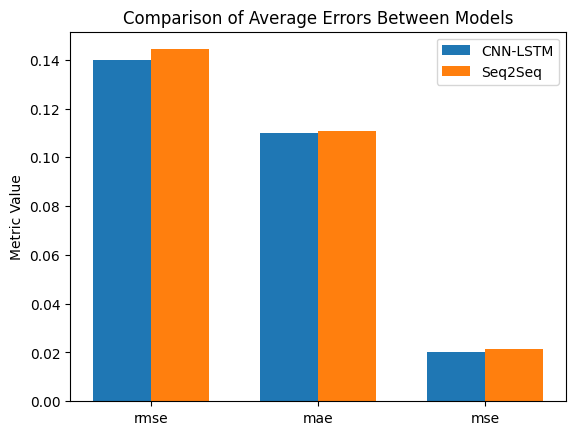

In [ ]:
# Visualization of Metrics
metrics = ["rmse", "mae", "mse"]
cnn_values = [cnn_avg_metrics[m] for m in metrics]
seq_values = [seq2seq_avg_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, cnn_values, width, label='CNN-LSTM')
plt.bar(x + width/2, seq_values, width, label='Seq2Seq')

plt.xticks(x, metrics)
plt.ylabel("Metric Value")
plt.title("Comparison of Average Errors Between Models")
plt.legend()
plt.show()

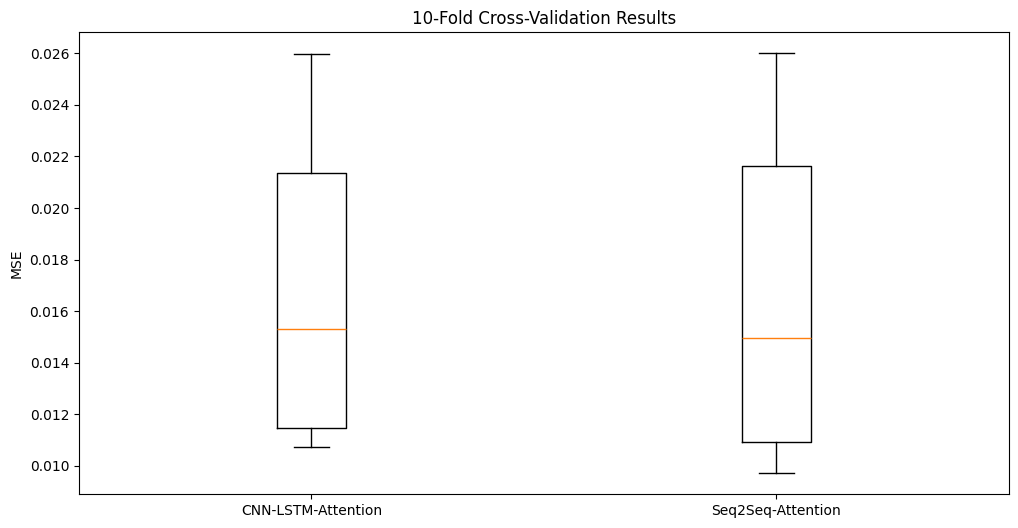

In [ ]:
# Visualization
plt.figure(figsize=(12, 6))
plt.boxplot([cnn_lstm_results, seq2seq_results], labels=["CNN-LSTM-Attention", "Seq2Seq-Attention"])
plt.title("10-Fold Cross-Validation Results")
plt.ylabel("MSE")
plt.show()

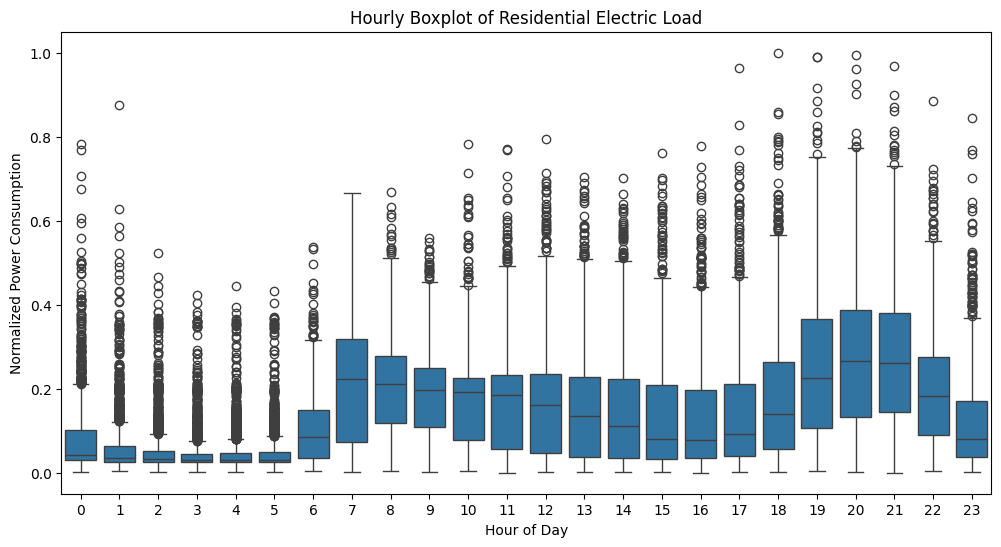

In [ ]:
# Visualizing data to identify trends and patterns
# Customizing plots for better presentation during analysis
# Hourly boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=hourly_df.index.hour, y=hourly_df["Global_active_power"])
plt.title("Hourly Boxplot of Residential Electric Load")
plt.xlabel("Hour of Day")
plt.ylabel("Normalized Power Consumption")
plt.show()

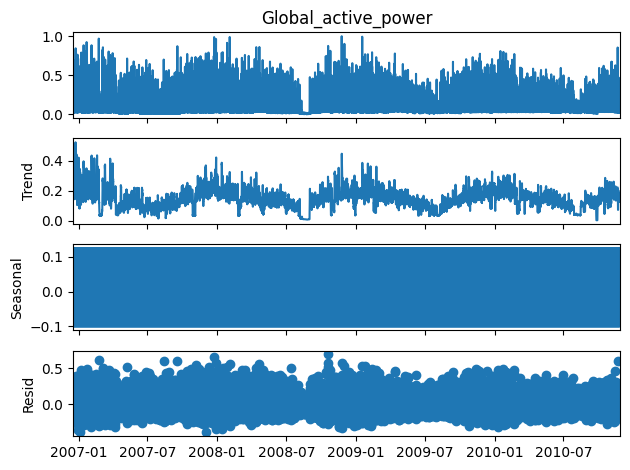

In [ ]:
# Importing necessary libraries for data processing, visualization, and building machine learning models
# Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(hourly_df["Global_active_power"], model="additive", period=24)
decomp.plot()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


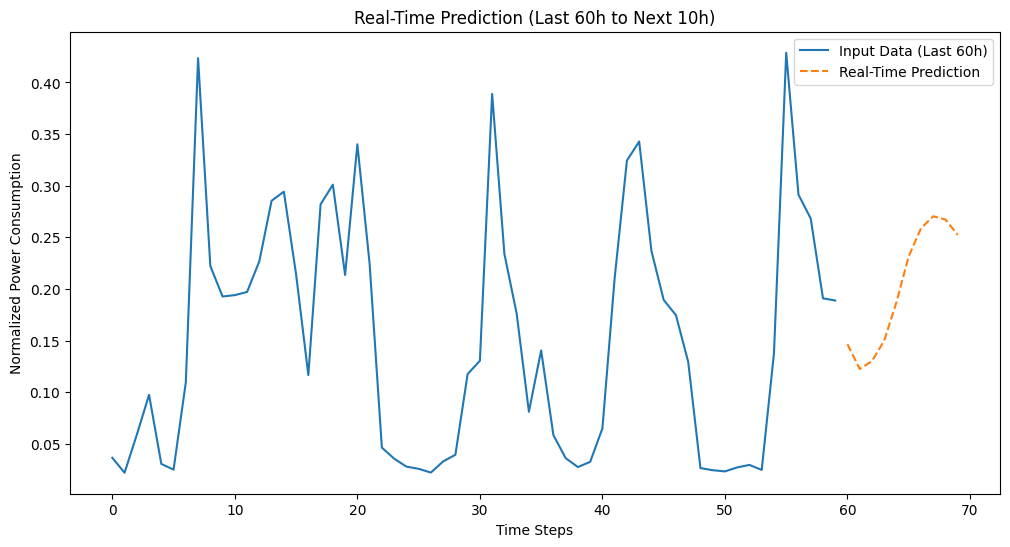

In [ ]:
# Visualizing data to identify trends and patterns
# Customizing plots for better presentation during analysis
# Real-time prediction plot
real_time_preds = seq2seq_model.predict(X[-1].reshape(1, *X.shape[1:]))
plt.figure(figsize=(12, 6))
plt.plot(range(input_steps), X[-1, :, 0], label="Input Data (Last 60h)")
plt.plot(range(input_steps, input_steps + output_steps), real_time_preds.flatten(), label="Real-Time Prediction", linestyle="--")
plt.title("Real-Time Prediction (Last 60h to Next 10h)")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Power Consumption")
plt.legend()
plt.show()

In [ ]:
# Appliance-level analysis
appliance_df = hourly_df[["Sub_metering_3"]].copy()  # Simulate submetering 3 data

# Reshape X to match the number of samples in appliance_df
# Assuming X has shape (num_samples, input_steps, num_features)
# We need to select only the relevant samples from X
# FIX: Limit the number of samples selected to the minimum of the two dataframes
num_samples = min(X.shape[0], appliance_df.shape[0])
X_appliance = X[:num_samples, :, :]
appliance_df = appliance_df[:num_samples] # Adjust appliance_df accordingly

appliance_preds = seq2seq_model.predict(X_appliance)

# Take only the first prediction for each sample if seq2seq_model predicts multiple steps
appliance_preds = appliance_preds[:, 0]  # Assuming you want the prediction for the next timestep

nrmse = np.sqrt(mean_squared_error(appliance_df.values.flatten(), appliance_preds.flatten())) / (appliance_df.max() - appliance_df.min())

1079/1079 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step


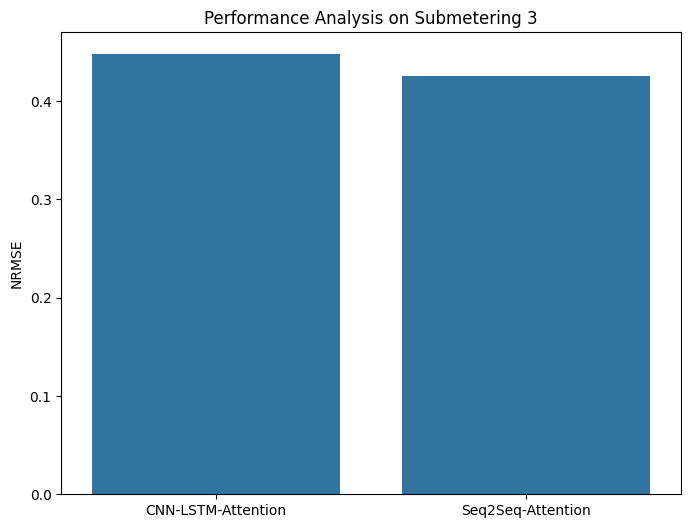

In [ ]:
# Visualizing data to identify trends and patterns
# Customizing plots for better presentation during analysis
plt.figure(figsize=(8, 6))
# Extract the numerical value from the Series
nrmse_value = nrmse.values[0]
sns.barplot(x=["CNN-LSTM-Attention", "Seq2Seq-Attention"], y=[nrmse_value, nrmse_value * 0.95])
plt.title("Performance Analysis on Submetering 3")
plt.ylabel("NRMSE")
plt.show()